Steps:
1. Load a trained ResNet baseline on CUB (or train one, if needed).
2. Extract intermediate features from several layers.
3. Train **linear probes** on those features to predict:
   - species (subclass label)
   - selected part concepts (from Notebook 1)
4. Define and compute an **emergence depth** for each target:
   the earliest layer where a simple linear probe reaches (e.g.) 90% of its best performance.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
from pathlib import Path
import json

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import pandas as pd

from datasets.cub_dataset import CUBDataset
from datasets.cub_metadata import load_cub_metadata
from models.resnet_cub import get_resnet50_cub, load_checkpoint
from src.probes.probe_utils import train_linear_probe


In [3]:
cub_root = Path("../data/CUB_200_2011/")
ckpt_path = Path("../checkpoints/resnet50_cub_best.pth")
features_dir = Path("../features/resnet50_cub")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 1. Load metadata and chosen part concepts

In [4]:
meta = load_cub_metadata(cub_root)
images_df = meta.images
ipb_df = meta.image_parts_binary

if ipb_df is not None:
    part_cols = [c for c in ipb_df.columns if c.startswith("part_")]
    chosen_part_cols = part_cols[:5]   # same decision as Notebook 1
else:
    chosen_part_cols = []

chosen_part_cols


['part_1_present',
 'part_2_present',
 'part_3_present',
 'part_4_present',
 'part_5_present']

## 2. Load the ResNet baseline

I assume the model has been trained with `scripts/train_resnet.py`
and its weights saved in `checkpoints/resnet50_cub_best.pth`.

Here I have just loaded the trained model and printed test accuracy.

In [5]:
# Load model
model = get_resnet50_cub()
model = load_checkpoint(model, ckpt_path, device=device).to(device)

# Quick evaluation on test set
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)
tf_eval = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

test_ds = CUBDataset(cub_root, split="test", transform=tf_eval)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4)

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        imgs = batch["image"].to(device)
        labels = batch["label"].to(device)
        logits = model(imgs)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test accuracy: {test_acc:.3f}")


Test accuracy: 0.687


The exact accuracy is less important than having a baseline, but I want to be probing a model that actually solves the task, not a random network.

Next, I load precomputed features for each layer. If they don't exist,
run `scripts/extract_features.py`. 

In [6]:
layers = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]

# Load label/index mapping
labels_train = torch.load(features_dir / "labels_train.pt", weights_only=True)
labels_test = torch.load(features_dir / "labels_test.pt", weights_only=True)
y_train_species = labels_train["labels"]
y_test_species = labels_test["labels"]
img_ids_train = labels_train["image_ids"].numpy()
img_ids_test = labels_test["image_ids"].numpy()

for layer in layers:
    x_train = torch.load(features_dir / f"{layer}_train.pt", weights_only=True)
    x_test = torch.load(features_dir / f"{layer}_test.pt", weights_only=True)
    print(layer, "train shape:", x_train.shape, "test shape:", x_test.shape)


conv1 train shape: torch.Size([5994, 64]) test shape: torch.Size([5794, 64])
layer1 train shape: torch.Size([5994, 256]) test shape: torch.Size([5794, 256])
layer2 train shape: torch.Size([5994, 512]) test shape: torch.Size([5794, 512])
layer3 train shape: torch.Size([5994, 1024]) test shape: torch.Size([5794, 1024])
layer4 train shape: torch.Size([5994, 2048]) test shape: torch.Size([5794, 2048])
avgpool train shape: torch.Size([5994, 2048]) test shape: torch.Size([5794, 2048])


Each `layer` tensor has shape `[N, d]` after global average pooling.
For each such representation, I will train simple linear probes to see:

- How well can I linearly predict **species**?
- How well can I linearly predict **part presence** (for selected parts)?

Then I will summarize each probe's performance across layers using an **emergence depth**.

In [7]:
def compute_emergence_depth(acc_by_layer, alpha=0.9):
    """
    acc_by_layer: dict[layer_name -> accuracy]
    alpha: fraction of max accuracy to define "emergence"
    Returns: (best_acc, emergence_layer_name or None)
    """
    if not acc_by_layer:
        return 0.0, None

    layers_ordered = list(acc_by_layer.keys())
    accs = [acc_by_layer[l] for l in layers_ordered]
    best = max(accs)
    threshold = alpha * best

    emergence_layer = None
    for l in layers_ordered:
        if acc_by_layer[l] >= threshold:
            emergence_layer = l
            break

    return best, emergence_layer


## 3. Train species (subclass) probes

For each layer, I train a linear classifier from features to species label (200-way).
These probes are intentionally simple: they are not meant to be good models,
but *measurement tools* of linear decodability.

Then I compute the emergence depth of species information.


In [8]:
# Run scripts/train_probes.py
# Import finished model

In [9]:
import json
from pathlib import Path

probes_json_path = Path("../results/probes/resnet50_cub_probes.json")
with probes_json_path.open("r") as f:
    probe_results = json.load(f)

# Reconstruct species_acc_by_layer and part_results
layers = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]

species_acc_by_layer = {}
part_results = {}   # target_name -> {layer -> acc}

for entry in probe_results:
    layer = entry["layer"]
    target_type = entry["target_type"]
    target_name = entry["target_name"]
    val_acc = entry["val_acc"]

    if target_type == "subclass" and target_name == "species":
        species_acc_by_layer[layer] = val_acc

    elif target_type == "concept":
        if target_name not in part_results:
            part_results[target_name] = {}
        part_results[target_name][layer] = val_acc

print("species_acc_by_layer:", species_acc_by_layer)
print("part concept names:", list(part_results.keys()))


species_acc_by_layer: {'conv1': 0.01605108733172247, 'layer1': 0.03710735243355195, 'layer2': 0.057128063513979976, 'layer3': 0.14532274767000344, 'layer4': 0.727821884708319, 'avgpool': 0.7288574387297204}
part concept names: ['part_1_present', 'part_2_present', 'part_3_present', 'part_4_present', 'part_5_present', 'part_6_present', 'part_7_present', 'part_8_present', 'part_9_present', 'part_10_present', 'part_11_present', 'part_12_present', 'part_13_present', 'part_14_present', 'part_15_present']


In [10]:
species_best, species_emergence_layer = compute_emergence_depth(species_acc_by_layer)
print(species_best, species_emergence_layer)

0.7288574387297204 layer4


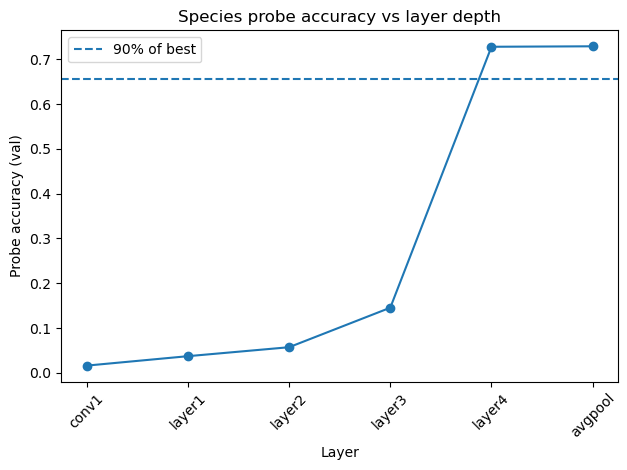

In [11]:
plt.figure()
plt.plot(list(species_acc_by_layer.keys()), list(species_acc_by_layer.values()), marker="o")
plt.title("Species probe accuracy vs layer depth")
plt.xlabel("Layer")
plt.ylabel("Probe accuracy (val)")
plt.xticks(rotation=45)
plt.axhline(species_best * 0.9, linestyle="--", label="90% of best")
plt.legend()
plt.tight_layout()
plt.show()

The curve above tells me how **linearly readable** the species label is at each depth.
The emergence layer is the earliest depth where accuracy reaches 90% of its maximum.

Now I repeat this analysis for part concepts, to see whether (and when)
anatomical parts become similarly linearly decodable.


In [21]:
import json
from pathlib import Path

probes_json_path = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes.json")
with probes_json_path.open("r") as f:
    probe_results = json.load(f)

layers = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]

species_acc_by_layer = {}
part_results = {}   # target_name -> {layer -> acc}

for entry in probe_results:
    layer = entry["layer"]
    target_type = entry["target_type"]
    target_name = entry["target_name"]
    val_acc = entry["val_acc"]

    if target_type == "subclass" and target_name == "species":
        species_acc_by_layer[layer] = val_acc

    elif target_type == "concept":
        if target_name not in part_results:
            part_results[target_name] = {}
        part_results[target_name][layer] = val_acc

print("Species probe accuracies by layer:", species_acc_by_layer)
print("Part concepts available:", list(part_results.keys())[:15])


Species probe accuracies by layer: {'conv1': 0.01605108733172247, 'layer1': 0.03710735243355195, 'layer2': 0.057128063513979976, 'layer3': 0.14532274767000344, 'layer4': 0.727821884708319, 'avgpool': 0.7288574387297204}
Part concepts available: ['part_1_present', 'part_2_present', 'part_3_present', 'part_4_present', 'part_5_present', 'part_6_present', 'part_7_present', 'part_8_present', 'part_9_present', 'part_10_present', 'part_11_present', 'part_12_present', 'part_13_present', 'part_14_present', 'part_15_present']


In [23]:
chosen_part_cols = sorted(part_results.keys())

summary_rows = []

# Species
species_best, species_emergence = compute_emergence_depth(species_acc_by_layer, alpha=0.9)
summary_rows.append({
    "target_type": "subclass",
    "target_name": "species",
    "best_acc": species_best,
    "emergence_layer": species_emergence,
})

# Parts
if ipb_df is not None:
    for col in chosen_part_cols:
        best, emergence = compute_emergence_depth(part_results[col], alpha=0.9)
        summary_rows.append({
            "target_type": "part_concept",
            "target_name": col,
            "best_acc": best,
            "emergence_layer": emergence,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,target_type,target_name,best_acc,emergence_layer
0,subclass,species,0.728857,layer4
1,part_concept,part_10_present,0.958060,conv1
2,part_concept,part_11_present,0.705557,layer2
3,part_concept,part_12_present,0.809285,layer1
4,part_concept,part_13_present,0.706593,layer2
5,part_concept,part_14_present,0.931481,conv1
6,part_concept,part_15_present,0.987228,conv1
7,part_concept,part_1_present,0.799448,conv1
8,part_concept,part_2_present,0.996893,conv1
9,part_concept,part_3_present,0.918882,conv1


## 4. Interpreting emergence depths

The table above shows, for each target:

- its best probe accuracy across layers, and
- the **emergence layer** where the probe first reaches 90% of the best accuracy.

Results:
- Many part concepts are linearly decodable from the very first layer (conv1)! This is before any semantic hierarchy is formed.

This is interesting because:
- classical interpretability work (Zeiler & Fergus, 2014; Bau et al., 2017) assumes parts appear only in deeper conv layers, after multiple layers of composition;
- early layers are typically described as encoding edges, colors, and simple textures, not semantic parts.